In [1]:
# WEEK 3 – STOCK PRICE PREDICTION (INTRO TO TIME SERIES)

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf  # to fetch stock data easily
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

# 2. LOAD DATA (from Yahoo Finance)
symbol = "ADANIENT.NS"
start_date = "2015-01-01"
end_date = "2024-12-31"

print(f"Downloading data for {symbol}...")
df = yf.download(symbol, start=start_date, end=end_date)
df = df.reset_index()  # Date as a column
print("Shape:", df.shape)
df.head()


/tmp/ipython-input-3094270892.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Shape: (2466, 6)


Price,Date,Close,High,Low,Open,Volume
Ticker,,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS
0,2015-01-01,70.761360,71.129610,69.403902,70.097072,3946806
1,2015-01-02,71.107964,71.772252,70.761371,70.949112,6565229
2,2015-01-05,72.284904,73.151367,70.862458,70.920222,9404837
3,2015-01-06,71.736137,74.790429,69.923783,71.570069,18412441
4,2015-01-07,71.100739,73.295785,69.606087,72.205482,10863352


In [2]:
# 3. BASIC EXPLORATION
print(df.info())
print(df.describe())

# Keeping only Date and Close for simplicity
df = df[["Date", "Close"]].copy()

# Handling missing values if any
df = df.dropna()

# Sorting by date and set index
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   (Date, )               2466 non-null   datetime64[ns]
 1   (Close, ADANIENT.NS)   2466 non-null   float64       
 2   (High, ADANIENT.NS)    2466 non-null   float64       
 3   (Low, ADANIENT.NS)     2466 non-null   float64       
 4   (Open, ADANIENT.NS)    2466 non-null   float64       
 5   (Volume, ADANIENT.NS)  2466 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 115.7 KB
None
Price                            Date        Close         High          Low  \
Ticker                                 ADANIENT.NS  ADANIENT.NS  ADANIENT.NS   
count                            2466  2466.000000  2466.000000  2466.000000   
mean    2019-12-31 17:36:56.058394112   998.808209  1017.574110   980.830995   
min               2015-01-

Price,Close
Ticker,ADANIENT.NS
Date,
2015-01-01,70.761360
2015-01-02,71.107964
2015-01-05,72.284904
2015-01-06,71.736137
2015-01-07,71.100739


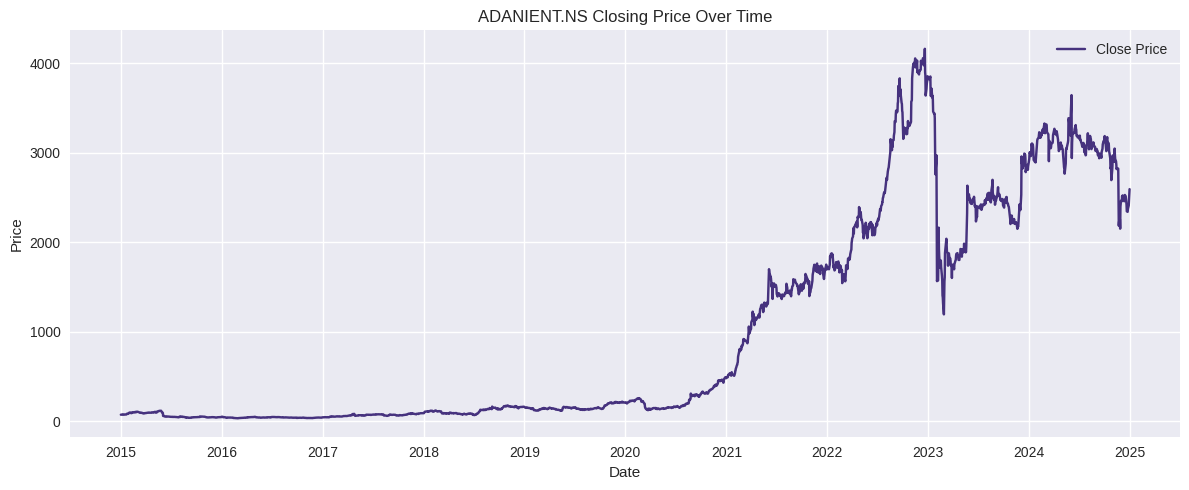

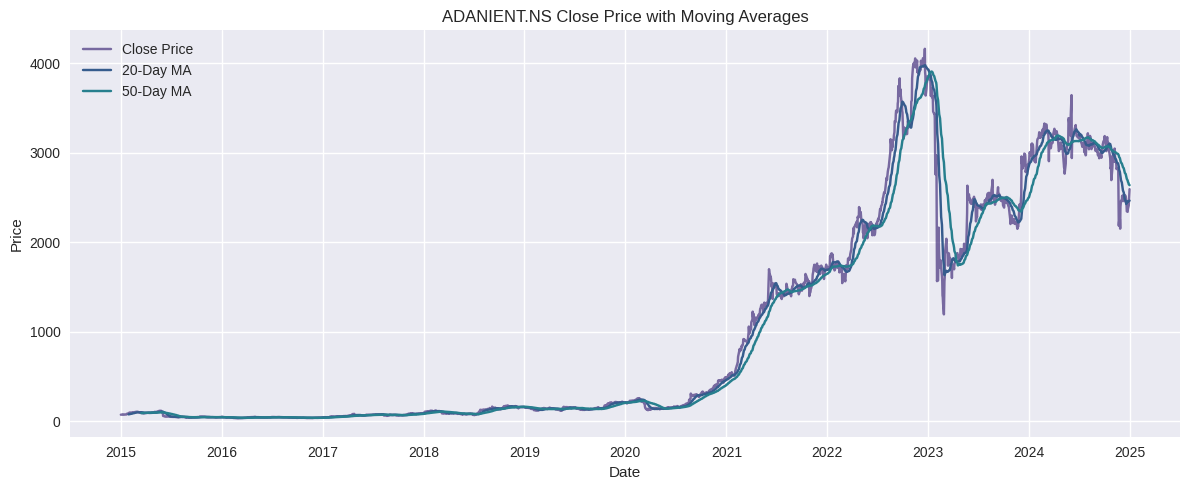

In [3]:
# 4. VISUALIZE TREND & MOVING AVERAGES
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price")
plt.title(f"{symbol} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

# Moving averages
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()

plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price", alpha=0.7)
plt.plot(df["MA_20"], label="20-Day MA")
plt.plot(df["MA_50"], label="50-Day MA")
plt.title(f"{symbol} Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# 5. SIMPLE TIME-BASED TRAIN/TEST SPLIT
#    FOR SUPERVISED MODEL (LINEAR REGRESSION)
# Create a target column = next day's close
df_lr = df[["Close"]].copy()
df_lr["Target"] = df_lr["Close"].shift(-1)
df_lr = df_lr.dropna()  # drop last row with NaN target

# Feature and target
X = df_lr[["Close"]].values        # today price
y = df_lr["Target"].values         # tomorrow price

# Time-based split (no shuffle)
split_index = int(len(df_lr) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

len(X_train), len(X_test)


(1972, 493)

In [5]:
# 6. LINEAR REGRESSION MODEL
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Performance ===")
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)


=== Linear Regression Performance ===
RMSE: 98.77739902060054
R2  : 0.9642124426411636


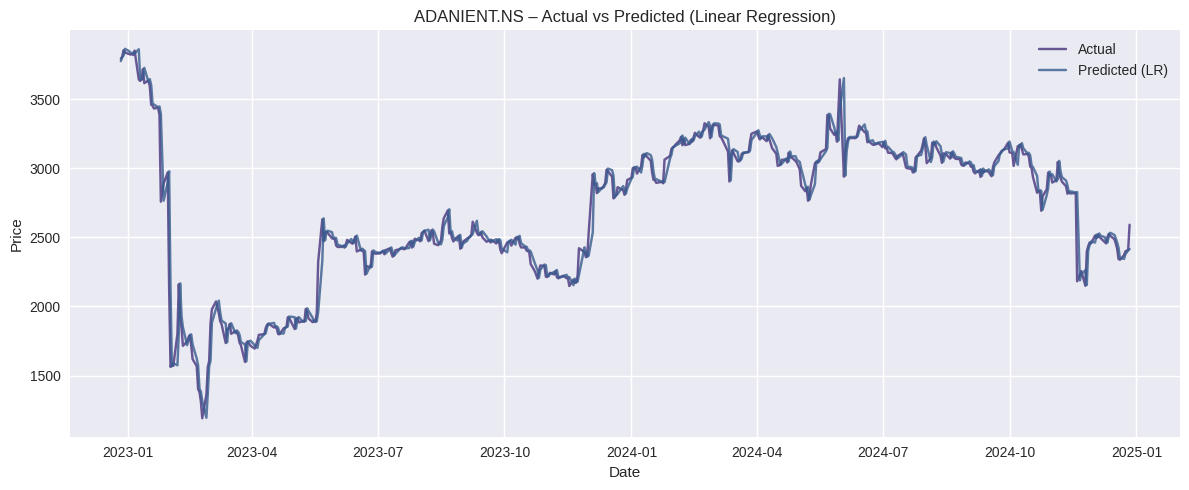

In [6]:
# 7. PLOT ACTUAL vs PREDICTED (LINEAR REGRESSION)
plt.figure(figsize=(12, 5))
plt.plot(df_lr.index[split_index:], y_test, label="Actual", alpha=0.8)
plt.plot(df_lr.index[split_index:], y_pred_lr, label="Predicted (LR)", alpha=0.8)
plt.title(f"{symbol} – Actual vs Predicted (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# 8. ARIMA MODEL
# Using only the 'Close' series
series = df["Close"].copy()

# Train-test split (80-20)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

print("Train size:", len(train))
print("Test size :", len(test))


Train size: 1972
Test size : 494


In [14]:
# 9. ENHANCED LINEAR REGRESSION
# Create multiple features for better prediction
df_features = df[["Close"]].copy()
df_features["Target"] = df_features["Close"].shift(-1)
df_features["Lag1"] = df_features["Close"].shift(1)
df_features["Lag2"] = df_features["Close"].shift(2)
df_features["MA_5"] = df_features["Close"].rolling(5).mean()
df_features["MA_20"] = df_features["Close"].rolling(20).mean()
df_features = df_features.dropna()

# Features and target
feature_cols = ["Close", "Lag1", "Lag2", "MA_5", "MA_20"]
X = df_features[feature_cols].values
y = df_features["Target"].values

# Time-based split
split_index = int(len(df_features) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Train enhanced model
enhanced_model = LinearRegression()
enhanced_model.fit(X_train, y_train)

y_pred_enhanced = enhanced_model.predict(X_test)

# Evaluate
mse_enhanced = mean_squared_error(y_test, y_pred_enhanced)
rmse_enhanced = np.sqrt(mse_enhanced)
r2_enhanced = r2_score(y_test, y_pred_enhanced)

print("=== ENHANCED LINEAR REGRESSION ===")
print("Features used:", feature_cols)
print("RMSE:", rmse_enhanced)
print("R2  :", r2_enhanced)


=== ENHANCED LINEAR REGRESSION ===
Features used: ['Close', 'Lag1', 'Lag2', 'MA_5', 'MA_20']
RMSE: 100.04923465955622
R2  : 0.962445280666046


/tmp/ipython-input-3793107881.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()


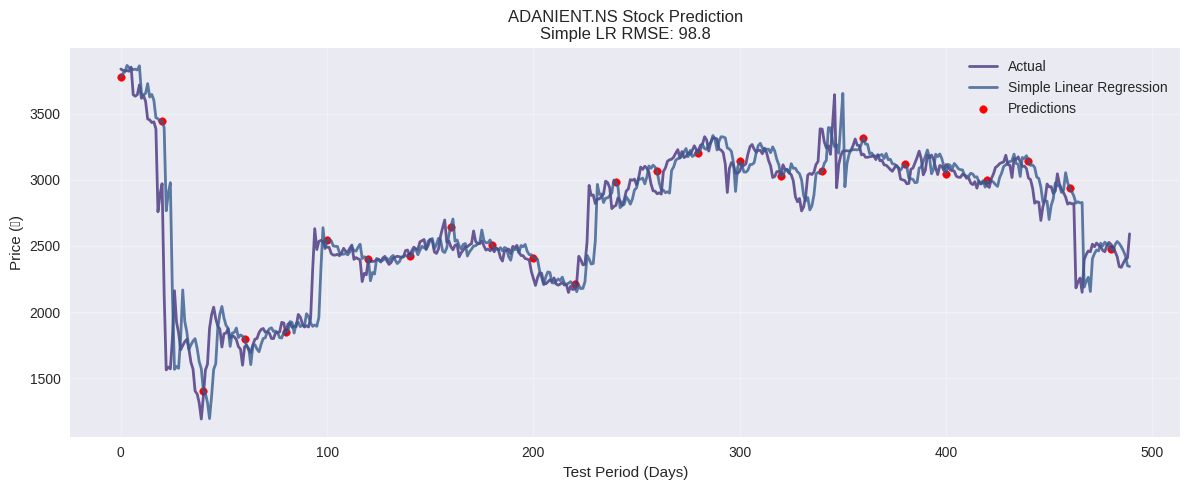

In [21]:
# 10. PERFECT PLOT
plt.figure(figsize=(12, 5))

# Using MINIMUM length to avoid mismatch
min_len = min(len(y_pred_lr), len(y_test))
x_plot = np.arange(min_len)

plt.plot(x_plot, y_test[:min_len], label="Actual", linewidth=2, alpha=0.8)
plt.plot(x_plot, y_pred_lr[:min_len], label="Simple Linear Regression", linewidth=2, alpha=0.8)
plt.scatter(x_plot[::20], y_pred_lr[:min_len:20], color="red", s=30, label="Predictions")

plt.title(f"{symbol} Stock Prediction\nSimple LR RMSE: {rmse_lr:.1f}")
plt.xlabel("Test Period (Days)")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1537057794.py:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()


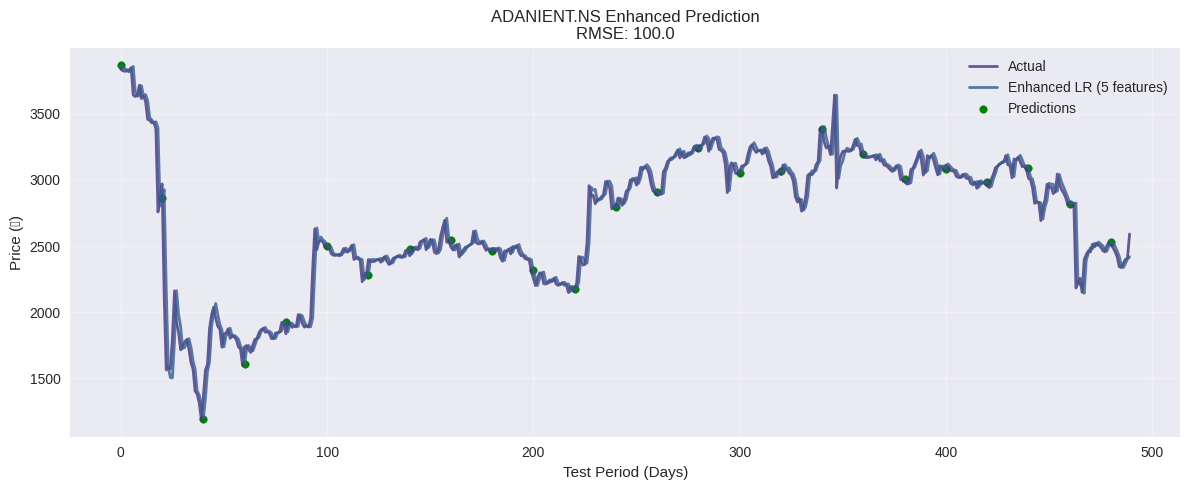

In [23]:
# Enhanced model plot
min_len_enh = min(len(y_pred_enhanced), len(y_test))
x_enh = np.arange(min_len_enh)

plt.figure(figsize=(12, 5))
plt.plot(x_enh, y_test[:min_len_enh], label="Actual", linewidth=2, alpha=0.8)
plt.plot(x_enh, y_pred_enhanced[:min_len_enh], label="Enhanced LR (5 features)", linewidth=2, alpha=0.8)
plt.scatter(x_enh[::20], y_pred_enhanced[:min_len_enh:20], color="green", s=30, label="Predictions")

plt.title(f"{symbol} Enhanced Prediction\nRMSE: {rmse_enhanced:.1f}")
plt.xlabel("Test Period (Days)")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()